# Module 6 — Multi-Seed Validation-Only LoRA Audit

**Objective:** measure how the revised rank-8 LoRA training protocol behaves across seeds 17, 42 and 73 while enforcing a validation-only model boundary.

**Claim boundary:** this is post-test exploratory work because Module 5 already observed BANKING77's official test result. This notebook loads only Module 6 manifests and validation reports. It does not load test predictions or compute test metrics.

**Success criteria:** three immutable manifests, three completed MPS runs, auditable early stopping, text-free evidence, and an aggregate that explicitly records no official-test access.

In [3]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook inside the project checkout.")


ROOT = find_project_root(Path.cwd())
registry = json.loads((ROOT / "data/manifests/banking77-multiseed-index.json").read_text())
runs = {
    seed: json.loads((ROOT / f"reports/multiseed-lora/seed-{seed}-validation.json").read_text())
    for seed in (17, 42, 73)
}
aggregate = json.loads((ROOT / "reports/multiseed-lora/validation-aggregate.json").read_text())
{
    "claim_scope": aggregate["claim_scope"],
    "seeds": aggregate["seeds"],
    "official_test_metrics_computed": aggregate["data_boundary"]["official_test_metrics_computed"],
    "aggregate_lock": aggregate["aggregate_sha256"][:12],
}

{'claim_scope': 'post_test_exploratory',
 'seeds': [17, 42, 73],
 'official_test_metrics_computed': False,
 'aggregate_lock': '85243a88f3eb'}

## Immutable split identities

Duplicate groups remain intact, so seeds can differ by two rows while preserving the stronger no-group-leakage requirement.

In [4]:
manifest_table = pd.DataFrame(registry["manifest_entries"]).set_index("seed")
manifest_table[
    [
        "train_rows",
        "validation_rows",
        "train_indices_sha256",
        "validation_indices_sha256",
    ]
]

,train_rows,validation_rows,train_indices_sha256,validation_indices_sha256
seed,,,,
17,8497,1499,4fab14309d52e7d5d75e072ea50ac2917f8a5483a667d6...,20b7e3f41c8d70de80a9cccb68360c37d8196345d06edd...
42,8495,1501,5a4325b55dc98a638e5c8bda91be4ec621babaa8ed9300...,9c66b4850a185873bd7af8a1736f2c32b42c2b0aaafcd0...
73,8497,1499,fc00a90876e613ed00fece6d307db2b70206bb8c425d25...,7a9141d6134fb5c2929be10870f2ce6af2f1c04465a90d...


## Validation trajectories and stopping decisions

The registered controller requires at least four epochs, allows at most eight, and stops after two epochs without a macro-F1 gain greater than 0.002. The best checkpoint is retained independently of the stopping epoch.

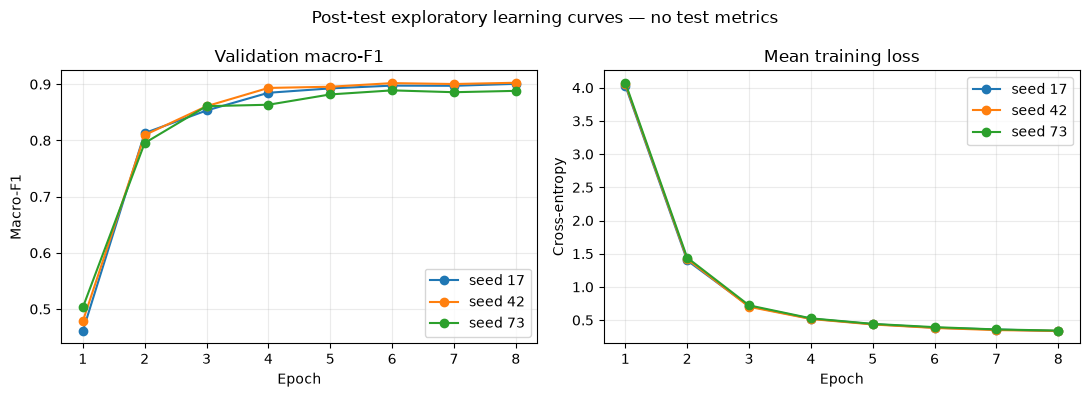

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for seed, run in runs.items():
    epochs = [row["epoch"] for row in run["epochs"]]
    macro_f1 = [row["validation"]["macro_f1"] for row in run["epochs"]]
    training_loss = [row["mean_training_loss"] for row in run["epochs"]]
    axes[0].plot(epochs, macro_f1, marker="o", label=f"seed {seed}")
    axes[1].plot(epochs, training_loss, marker="o", label=f"seed {seed}")
axes[0].set(title="Validation macro-F1", xlabel="Epoch", ylabel="Macro-F1")
axes[1].set(title="Mean training loss", xlabel="Epoch", ylabel="Cross-entropy")
for axis in axes:
    axis.set_xticks(range(1, 9))
    axis.grid(alpha=0.25)
    axis.legend()
fig.suptitle("Post-test exploratory learning curves — no test metrics")
fig.tight_layout()

In [6]:
run_table = pd.DataFrame(
    [
        {
            "seed": seed,
            "best_epoch": run["best_epoch"],
            "epochs_completed": run["epochs_completed"],
            "validation_macro_f1": run["best_validation_metrics"]["macro_f1"],
            "validation_accuracy": run["best_validation_metrics"]["accuracy"],
            "validation_log_loss": run["best_validation_metrics"]["log_loss"],
            "stopping_reason": run["stopping_reason"],
            "training_minutes": run["training_seconds"] / 60,
            "device": run["runtime_device"]["selected"],
        }
        for seed, run in runs.items()
    ]
).set_index("seed")
run_table.round(4)

,best_epoch,epochs_completed,validation_macro_f1,validation_accuracy,validation_log_loss,stopping_reason,training_minutes,device
seed,,,,,,,,
17,8,8,0.9006,0.8993,0.3486,maximum_epochs_reached,27.9925,mps
42,8,8,0.9026,0.9001,0.3643,validation_patience_exhausted,22.9066,mps
73,6,8,0.8890,0.8879,0.4054,validation_patience_exhausted,33.9057,mps


## Aggregate validation evidence

The interval below is descriptive. With three seeds, it is not a confirmatory uncertainty estimate and says nothing directly about production traffic or the already observed benchmark test.

In [7]:
summary_rows = []
for metric, details in aggregate["validation_metrics"].items():
    summary_rows.append(
        {
            "metric": metric,
            "mean": details["mean"],
            "sample_sd": details["sample_standard_deviation"],
            "ci95_low": details["confidence_interval_95"][0],
            "ci95_high": details["confidence_interval_95"][1],
        }
    )
pd.DataFrame(summary_rows).set_index("metric").round(4)

,mean,sample_sd,ci95_low,ci95_high
metric,,,,
accuracy,0.8958,0.0068,0.8789,0.9126
balanced_accuracy,0.8961,0.0062,0.8808,0.9114
log_loss,0.3728,0.0293,0.2999,0.4456
macro_f1,0.8974,0.0073,0.8792,0.9156
mean_max_confidence_uncalibrated,0.8632,0.0024,0.8572,0.8691
top_3_accuracy,0.9707,0.0047,0.9591,0.9823
weighted_f1,0.8955,0.0072,0.8777,0.9133


## Machine-checked boundary and integrity assertions

In [8]:
from governed_banking.baseline import assert_text_free_artifact
from governed_banking.data import stable_json_sha256


def content_hash_valid(artifact: dict, field: str) -> bool:
    body = dict(artifact)
    expected = body.pop(field)
    return expected == stable_json_sha256(body)


assert_text_free_artifact(registry)
assert_text_free_artifact(aggregate)
assert registry["model_access_boundary"]["prohibited_splits"] == ["test"]
assert aggregate["claim_scope"] == "post_test_exploratory"
assert aggregate["data_boundary"]["loaded_model_splits"] == ["train", "validation"]
assert aggregate["data_boundary"]["test_split_loaded"] is False
assert aggregate["data_boundary"]["official_test_metrics_computed"] is False
assert content_hash_valid(registry, "registry_sha256")
assert content_hash_valid(aggregate, "aggregate_sha256")
for run in runs.values():
    assert_text_free_artifact(run)
    assert run["data_boundary"]["test_split_loaded"] is False
    assert run["data_boundary"]["official_test_metrics_computed"] is False
    assert content_hash_valid(run, "run_sha256")
{
    "text_free": True,
    "validation_only": True,
    "test_metrics_computed": False,
    "all_content_hashes_valid": True,
}

{'text_free': True,
 'validation_only': True,
 'test_metrics_computed': False,
 'all_content_hashes_valid': True}

## Decision

The revised protocol produced 0.8974 mean validation macro-F1 with 0.0073 sample SD. It corrected the obvious three-epoch budget problem, but seeds 17 and 42 still peaked at epoch eight. Do not extend BANKING77 training again and claim benchmark improvement. Preserve this as exploratory development evidence, obtain an independent confirmation set for performance claims, and proceed to calibration only with a separated validation-development and calibration-assessment design.